In [79]:
! pip install opencv-python

In [80]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings
from torch import nn,optim,utils
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import gc

filterwarnings(action='ignore')

gc.collect()

3207

In [81]:
device='cuda' if torch.cuda.is_available() else 'cpu'   

In [82]:
transform = transforms.Compose([
    transforms.ToTensor(),
])


trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = utils.data.DataLoader(trainset, batch_size=200, shuffle=True, num_workers=2)

In [83]:
class Encoder(nn.Module):
    def __init__(self,embed_size):
        super(Encoder,self).__init__()
      
        self.conv1=nn.Conv2d(in_channels=1,out_channels=4,kernel_size=(3,3),stride=2, padding=1)
        self.batchnorm1=nn.BatchNorm2d(4)
        self.conv2=nn.Conv2d(in_channels=4,out_channels=8,kernel_size=(3,3),stride=2,padding=1)
        self.batchnorm2=nn.BatchNorm2d(8)

        self.relu = nn.ReLU()
        self.hid1=nn.Linear(8*7*7,64)
        self.hid2=nn.Linear(64,32)
        self.mu = nn.Linear(32, embed_size)
        self.sigma = nn.Linear(32, embed_size)

    def forward(self,X):
        x = self.batchnorm1(self.relu(self.conv1(X)))
        x = self.batchnorm2(self.relu(self.conv2(x)))
        x= x.view(-1,8*7*7)
        x=self.relu(self.hid1(x))
        x=self.relu(self.hid2(x))

        return self.mu(x), self.sigma(x)

In [84]:
class Decoder(nn.Module):
    def __init__(self,embed_size):
        super(Decoder,self).__init__()
        
        self.linear1=nn.Linear(embed_size,32)
        self.linear2=nn.Linear(32,64)
        self.linear3=nn.Linear(64,8*7*7)
        self.conv1=nn.ConvTranspose2d(in_channels=8,out_channels=4,kernel_size=(3,3),stride=2,output_padding=1, padding=1)
        self.batchnorm1=nn.BatchNorm2d(4)
        self.conv2=nn.ConvTranspose2d(in_channels=4,out_channels=1,kernel_size=(3,3),stride=2,output_padding=1, padding=1)
        
        self.relu = nn.ReLU()
        self.sigmoid=nn.Sigmoid()
        
    def forward(self,X):
        x = self.relu(self.linear1(X))
        x =self.relu(self.linear2(x))
        x=self.relu(self.linear3(x))
        x = x.view(-1, 8,7,7)
        
        x = self.batchnorm1(self.relu(self.conv1(x)))
        x = self.conv2(x)
        
        x =self.sigmoid(x)
        
        return x

In [85]:
class Vae(nn.Module):
    def __init__(self,embed_size):
        super(Vae,self).__init__()
        
        self.embed_size=embed_size
        self.encoder=Encoder(self.embed_size)
        self.decoder=Decoder(self.embed_size)
        
    def find_sample(self,mu,sigma):
        std = torch.exp(0.5 * sigma)
        epsilon = torch.randn_like(std,device=device)
        
        return epsilon.mul(std).add_(mu)
        
    def forward(self,X):
        mu,sigma=self.encoder(X)
        
        return self.decoder(self.find_sample(mu,sigma)),mu,sigma
    
    def reconstruct_from_distribution(self,mu,sigma):
        
        return self.decoder(self.find_sample(mu,sigma))

In [86]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear) or isinstance(m,nn.ConvTranspose2d):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

In [87]:
vae_model=Vae(embed_size=2)
vae_model.apply(init_weights)
vae_model.to(device)

Vae(
  (encoder): Encoder(
    (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (batchnorm1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (batchnorm2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (hid1): Linear(in_features=392, out_features=64, bias=True)
    (hid2): Linear(in_features=64, out_features=32, bias=True)
    (mu): Linear(in_features=32, out_features=2, bias=True)
    (sigma): Linear(in_features=32, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (linear1): Linear(in_features=2, out_features=32, bias=True)
    (linear2): Linear(in_features=32, out_features=64, bias=True)
    (linear3): Linear(in_features=64, out_features=392, bias=True)
    (conv1): ConvTranspose2d(8, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (batchnorm1): Batch

In [88]:
def train(images,vae_model,num_epoch,loss_func,optimizer):
    for epoch in range(num_epoch):
        total_loss=0
        for batch_idx,(img,label) in enumerate(images):
            vae_model.train()
            result,mu,sigma=vae_model(img.to(device))
            # recostruction loss
            reconstructed_loss = loss_func(result.to(device), img.to(device))
            # kl divergence
            kl_div = -0.5 * torch.sum(1 + sigma - mu.pow(2) - sigma.exp())
            # total
            loss = reconstructed_loss + kl_div
            
            total_loss += loss.item()
            
            optimizer.zero_grad()
            loss.backward()
            
            optimizer.step()
            
            torch.nn.utils.clip_grad_norm_(vae_model.parameters(), 1.0)
            
        print('Epoch: {} Average loss: {:.4f}'.format(epoch+1,total_loss/ len(images.dataset)))
        total_loss=0.0
    return

In [89]:
loss_func = nn.BCELoss(reduction="sum")
adam = optim.Adam(vae_model.parameters())
num_epoch=100

In [90]:
train(trainloader,vae_model,num_epoch,loss_func,adam)

Epoch: 1 Average loss: 390.8739
Epoch: 2 Average loss: 206.8354
Epoch: 3 Average loss: 170.1924
Epoch: 4 Average loss: 161.2255
Epoch: 5 Average loss: 157.3861
Epoch: 6 Average loss: 155.1953
Epoch: 7 Average loss: 153.6209
Epoch: 8 Average loss: 152.5200
Epoch: 9 Average loss: 151.7067
Epoch: 10 Average loss: 150.9098
Epoch: 11 Average loss: 150.3617
Epoch: 12 Average loss: 149.6747
Epoch: 13 Average loss: 149.3260
Epoch: 14 Average loss: 148.9500
Epoch: 15 Average loss: 148.4747
Epoch: 16 Average loss: 148.1555
Epoch: 17 Average loss: 147.9538
Epoch: 18 Average loss: 147.6038
Epoch: 19 Average loss: 147.3803
Epoch: 20 Average loss: 147.2108
Epoch: 21 Average loss: 147.0273
Epoch: 22 Average loss: 146.7798
Epoch: 23 Average loss: 146.7280
Epoch: 24 Average loss: 146.5112
Epoch: 25 Average loss: 146.2882
Epoch: 26 Average loss: 146.1195
Epoch: 27 Average loss: 146.0184
Epoch: 28 Average loss: 145.8940
Epoch: 29 Average loss: 145.7544
Epoch: 30 Average loss: 145.6644
Epoch: 31 Average l

In [95]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

In [96]:
with torch.no_grad():
    result,_,_=vae_model(images.to(device))

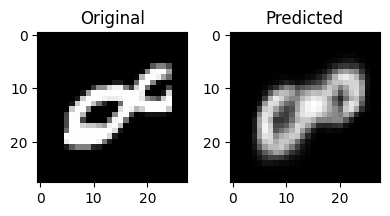

In [97]:
fig, axs = plt.subplots(1, 2, figsize=(4, 4))

origin=images[0].T.cpu().numpy()*255.0
predict=result[0].T.cpu().detach().numpy()*255.0

axs[0].imshow(origin.astype(np.uint8), cmap='gray')
axs[0].set_title('Original')

axs[1].imshow(predict.astype(np.uint8), cmap='gray')
axs[1].set_title('Predicted')

plt.tight_layout()

plt.show()